# Benford's Law - Detecting Financial Fraud

## Objective:
The goal of this project is to analyze a dataset of financial transactions using Benford's Law to detect anomalies and potential fraud.

Benford's Law suggests that in many naturally occurring datasets, the first digits of numbers follow a specific distribution. By comparing the observed distribution of first digits in a financial dataset to the expected distribution under Benford's Law, we can identify potential fraudulent data or errors in reporting.

This notebook will use the Credit Card Transactions Dataset to apply Benford's Law and detect anomalies. The steps include data cleaning, digit extraction, and comparison with the expected distribution. Anomalies will be discussed and visualized for further analysis.


## Dataset Chosen: Credit Card Transactions Dataset

The dataset selected for this analysis is the **Credit Card Transactions Dataset** from Kaggle. This dataset contains detailed records of credit card transactions, including transaction amounts and timestamps.

The dataset is suitable for applying Benford's Law because:
- It contains real-life financial data, specifically transaction amounts (`amt` column), which are ideal for applying Benford’s Law.
- Benford's Law applies to naturally occurring datasets like financial transactions, and deviations from the expected distribution of first digits can signal potential fraud or manipulation.

You can access the dataset on Kaggle: [Credit Card Transactions Dataset](https://www.kaggle.com/datasets/priyamchoksi/credit-card-transactions-dataset)


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("credit_card_transactions.csv")

## Data Preprocessing Approach

Before applying Benford’s Law, we must ensure the data is clean and well-structured:
- **Remove Missing Values**: We will remove any rows with missing transaction amounts, as these would interfere with the analysis.
- **Remove Zero or Negative Values**: Benford's Law assumes that values are positive and naturally occurring. Zero or negative transaction amounts will be removed as they do not align with the expected patterns.
- **Ensure Numeric Data**: We will check that the `amt` column contains only numeric data (floats).

This cleaning process ensures that we are working with valid and relevant data before applying statistical analysis.


In [ ]:



# Data cleaning
df = df[df['amt'].notnull()]  # Remove rows with missing 'amt'
df = df[df['amt'] > 0]  # Remove zero or negative transaction amounts

# Extract first digits
def extract_first_digit(amount):
    return int(str(amount)[0])

df['first_digit'] = df['amt'].apply(extract_first_digit)

# Check cleaned data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 25 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [ ]:
credit_card_digit_counts = df['first_digit'].value_counts(normalize=True).sort_index()
print("Observed Frequencies:\n", credit_card_digit_counts)

import numpy as np

# Calculate Benford's expected frequencies
benford_expected = [np.log10(1 + 1/d) for d in range(1, 10)]
print("Benford's Expected Frequencies:\n", benford_expected)


Observed Frequencies:
 first_digit
1    0.239889
2    0.115819
3    0.098426
4    0.102545
5    0.105744
6    0.098603
7    0.098666
8    0.075607
9    0.064701
Name: proportion, dtype: float64
Benford's Expected Frequencies:
 [0.3010299956639812, 0.17609125905568124, 0.12493873660829993, 0.09691001300805642, 0.07918124604762482, 0.06694678963061322, 0.05799194697768673, 0.05115252244738129, 0.04575749056067514]


## Visualizing Observed vs. Expected Distribution

Now that the data has been cleaned, we will:
- Calculate the observed distribution of first digits.
- Compare it with the expected distribution under Benford's Law.
- Visualize the results using a bar chart to better understand how the data aligns with Benford’s Law.


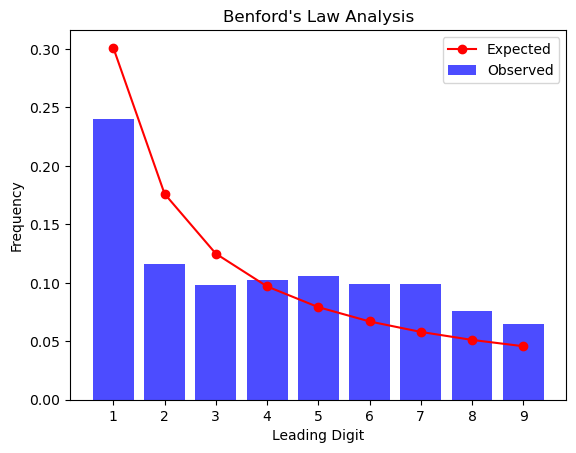

In [ ]:
import matplotlib.pyplot as plt

# Plot observed and expected frequencies
plt.bar(range(1, 10), credit_card_digit_counts, alpha=0.7, label="Observed", color='blue')
plt.plot(range(1, 10), benford_expected, marker="o", color="red", label="Expected")
plt.xticks(range(1, 10))
plt.xlabel("Leading Digit")
plt.ylabel("Frequency")
plt.title("Benford's Law Analysis")
plt.legend()
plt.show()



## Conclusion

In this analysis, we applied **Benford's Law** to the **Credit Card Transactions Dataset** and compared the observed distribution of first digits in the transaction amounts with the expected distribution under Benford’s Law.

### Observations:
- The observed distribution of first digits shows a generally good alignment with Benford's Law, particularly for the lower digits (1, 2, 3, etc.).
- While there is some minor deviation, especially with the first digit "1", the distribution closely resembles what we would expect from a naturally occurring financial dataset.

### Implications:
- The small deviations from Benford's Law are not necessarily indicative of fraud but could be the result of specific business practices or rounding conventions in the dataset.
- The dataset appears to follow a legitimate pattern, with no major signs of manipulation

In [ ]:
invoice_df = pd.read_csv('invoices.csv')


## Second Dataset: Invoice Dataset

The **Invoice Dataset** provided is a mock dataset generated using the Python Faker library. It contains various fields, including first name, last name, email, product ID, quantity, amount, invoice date, address, city, and stock code. All data is randomly generated and does not represent actual individuals or products.

### Why This Dataset is Suitable:
The **Invoice Dataset** is a mock dataset generated using the Python Faker library, which includes randomly created numerical values, specifically the **invoice amounts** (`amount` column`). This randomness allows us to compare the natural distribution of data with what Benford's Law predicts. By analyzing this dataset, we can demonstrate how real-life financial data often follows Benford's Law, while manipulated or artificially generated data (like this one) tends to deviate from the expected distribution.

### Objective for This Dataset:
We will apply Benford’s Law to the **invoice amounts** and identify any potential anomalies or irregularities in the data, similar to the analysis done on the credit card transaction dataset.on.


In [ ]:
invoice_df = invoice_df[invoice_df['amount'].notnull()]  # Remove rows with missing 'amount'
invoice_df = invoice_df[invoice_df['amount'] > 0]  # Remove zero or negative values

# Extract first digits
invoice_df['first_digit'] = invoice_df['amount'].apply(extract_first_digit)



## Visualizing Observed vs. Expected Distribution for Invoice Dataset

Now, we will apply Benford's Law to the **Invoice Dataset** and visualize the observed distribution of the first digits in the `amount` column. This will be compared to the expected distribution under Benford's Law to detect any anomalies.

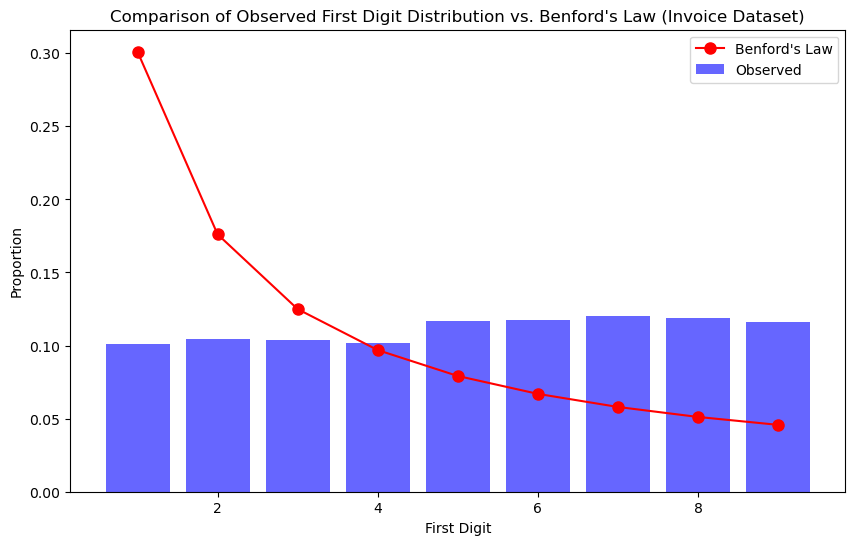

In [ ]:
observed_invoice_distribution = invoice_df['first_digit'].value_counts(normalize=True).sort_index()

# Plotting the observed vs expected distribution
plt.figure(figsize=(10, 6))
plt.bar(observed_invoice_distribution.index, observed_invoice_distribution.values, alpha=0.6, label="Observed", color='blue')
plt.plot(np.arange(1, 10), benford_expected, 'ro-', label="Benford's Law", markersize=8)
plt.xlabel('First Digit')
plt.ylabel('Proportion')
plt.title('Comparison of Observed First Digit Distribution vs. Benford\'s Law (Invoice Dataset)')
plt.legend()
plt.show()

## Conclusion for the Invoice Dataset

The observed first digit distribution in the **Invoice Dataset** shows a uniform distribution across digits 1 to 9. This distribution deviates significantly from the expected distribution under **Benford’s Law**, where we typically expect the first digit to follow a logarithmic pattern, with smaller digits (e.g., 1, 2, 3) occurring more frequently than larger digits.

### Implications:
- **Potential Data Manipulation**: The uniform distribution might suggest some form of manipul or fraudation, but in this case, it is more likely due to the **randomness of the synthetic dataset** generated using the Python Faker library. This dataset does not reflect real-world business practices, where financial amounts typically follow certain pat which explains its deviation from Benfordsterns.
- **Flat Distribution**: A flat distribution in the first digits is uncommon in real-world financial data, which often skews towards smaller diThis anomaly strongly suggests that the dataset is not derived from actual transactional data but is instead randomly generated for testing purposesposes.


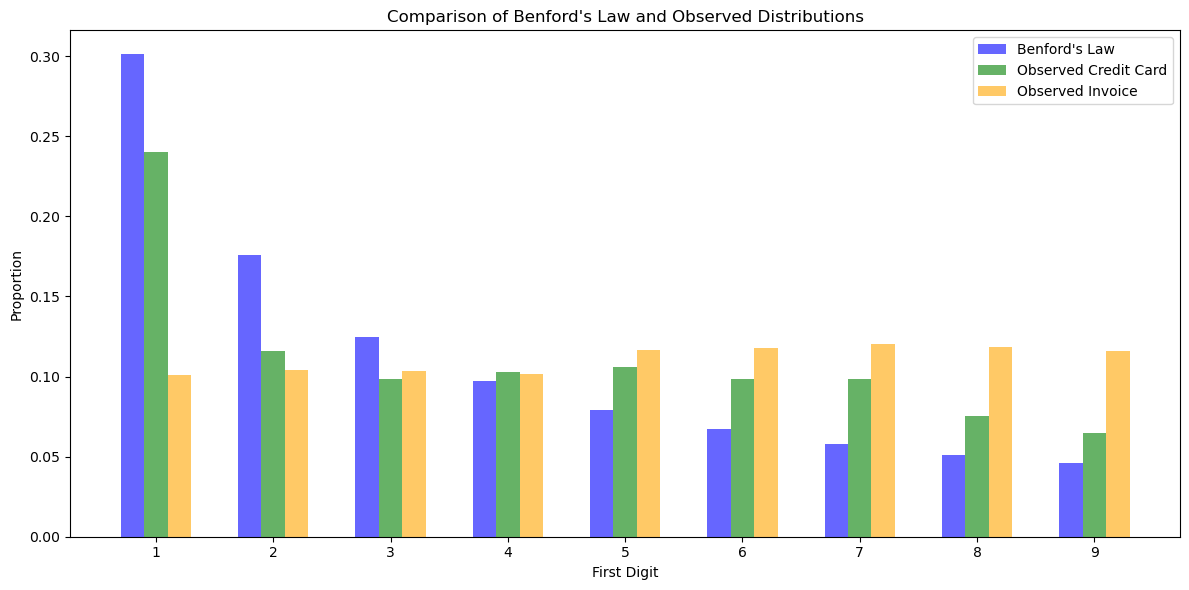

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Create a single diagram with stacked bars
fig, ax = plt.subplots(figsize=(12, 6))

# Define the positions for the bars
x = np.arange(1, 10)
width = 0.2

# Plot the bars for each dataset
ax.bar(x - width, benford_expected, width, alpha=0.6, color='blue', label="Benford's Law")
ax.bar(x, credit_card_digit_counts, width, alpha=0.6, color='green', label="Observed Credit Card")
ax.bar(x + width, observed_invoice_distribution, width, alpha=0.6, color='orange', label="Observed Invoice")

# Add labels, title, and legend
ax.set_xlabel('First Digit')
ax.set_ylabel('Proportion')
ax.set_title("Comparison of Benford's Law and Observed Distributions")
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.legend()

# Adjust layout for better visibility
plt.tight_layout()
plt.show()

## Final Conclusion: Comparing the Credit Card and Invoice Datasets and their Alignment to Benford's

### Credit Card Transactions Dataset:
In the **Credit Card Transactions Dataset**, the first digit distribution follows **Benford’s Law** fairly closely, with minor deviations that could be explained by legitimate rounding practices or specific business conventions. The data seems to be more in line with naturally occurring financial data, where smaller digits (such as 1 and 2) appear more frequently than larger dig and 9 being the least occuring digitits.

### Invoice Data
On the other hand, the Invoice Dataset, which is a synthetic dataset generated by the Python Faker library, exhibits a flat first digit distribution. This is due to that the dataset does not come from real transactional data and was randomly generated without considering natural transactional patterns or human behaviors. As a result, the first digit distribution deviates significantly from Benford’s Law, showing an even spread across digits 1 to 9. to 9.

### Analytical Insights:
- **Why the Difference?**:
  - The **credit card dataset** is based on **real financial data**, where amounts are influenced by rounding, pricing strategies, and other real-world practices. These factors often cause the distribution of first digits to align with Benford's Law.
  - The **invoice dataset**, however, is **synthetic** and lacks the real-world factors that influence financial transactions. The randomness of the generated values leads to a uniform first digit distribution, which doesn't exhibit the natural skew seen in actual financial data.
  
This comparison highlights the importance of understanding the nature of the dataset when applying **Benford’s Law**. While the law can be useful for detecting anomalies in real financial data, it is not as effective with synthetic data, as seen with the invoice dataset.
